# Data Science Job Salaries Dataset

The dataset contains **11 columns**:

| Column Name | Description                                                  |
| :--- |:-------------------------------------------------------------|
| **`work_year`** | The year when the salary was paid.                           |
| **`experience_level`** | The experience level in the job during the year.             |
| **`employment_type`** | The type of employment for the role.                         |
| **`job_title`** | The role worked in during the year.                          |
| **`salary`** | The total gross salary amount paid.                          |
| **`salary_currency`** | The currency of the salary paid.                             |
| **`salaryinusd`** | The salary in USD.                                           |
| **`employee_residence`** | Employee's primary country of residence during the work year |
| **`remote_ratio`** | The overall amount of work done remotely.                    |
| **`company_location`** | The country of the employer's main office.                   |
| **`company_size`** | Size of the company.                                         |

### STEP 1: LOAD DATA
### We need to import our dataset to work with it

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ds_salaries.csv')
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


### Data Cleaning
### Remove duplicates and outliers that could negatively affect model training
### Using IQR method to detect salary outliers

In [77]:
dublicates = df.duplicated().sum()
df.drop_duplicates()
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

df = df[(df['salary_in_usd'] >= lower_bound) & (df['salary_in_usd'] <= upper_bound)]
print(f"size of dataset after cleaning: {df.shape[0]}")

size of dataset after cleaning: 3750


### EXPLORATORY DATA ANALYSIS (EDA)
### Understand data distribution and relationships between features
### Visualize key patterns that will help us build better models

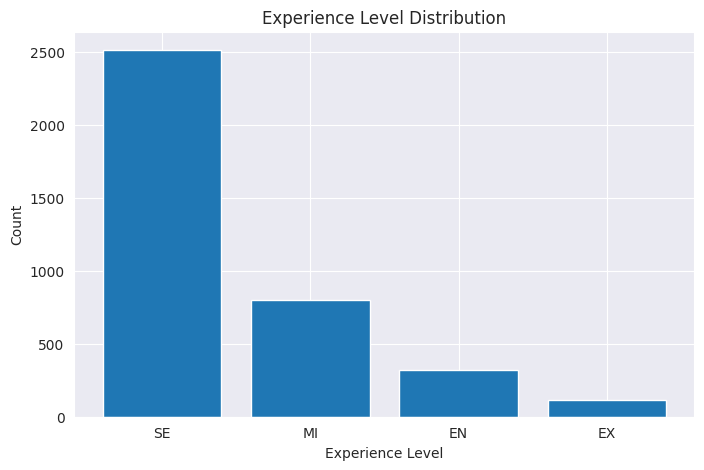

In [78]:
exp_dist = df['experience_level'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(exp_dist.index, exp_dist.values)
plt.title('Experience Level Distribution')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.show()

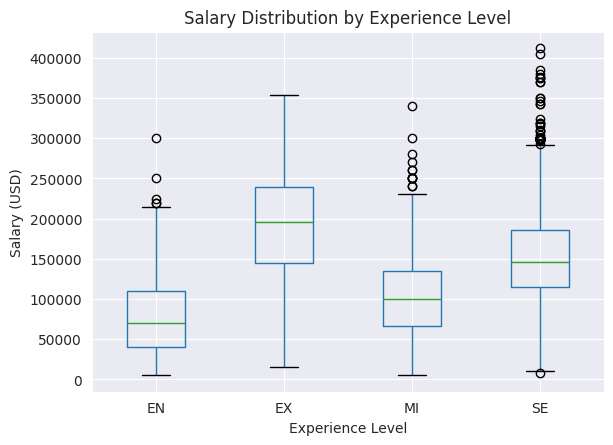

In [79]:
df.boxplot(column='salary_in_usd', by='experience_level')
plt.suptitle('')
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

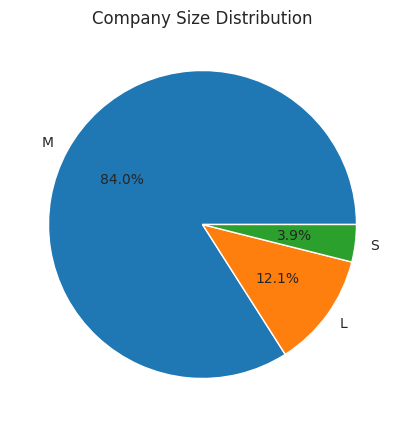

In [80]:
size_dist = df['company_size'].value_counts()
plt.figure(figsize=(8, 5))
plt.pie(size_dist.values, labels=size_dist.index, autopct='%1.1f%%')
plt.title('Company Size Distribution')
plt.show()

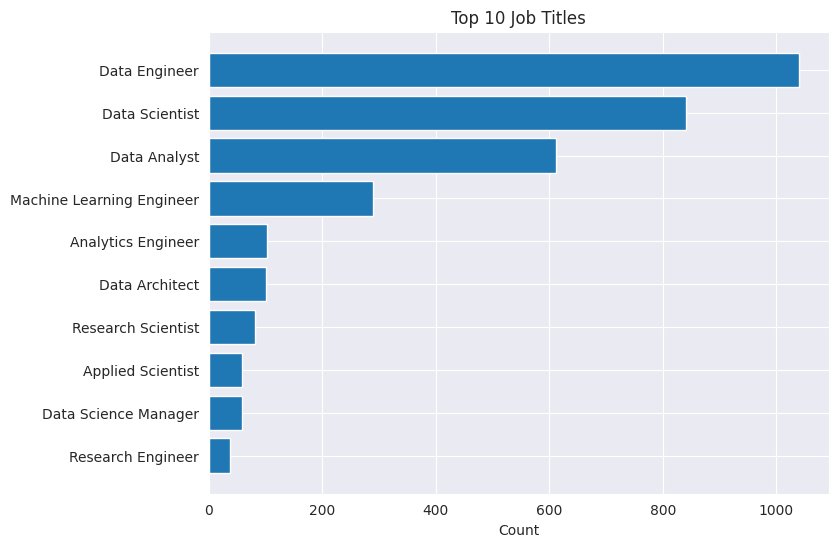

In [81]:
top_jobs = df['job_title'].value_counts().head(10)
plt.figure(figsize=(8, 6))
plt.barh(range(len(top_jobs)), top_jobs.values)
plt.yticks(range(len(top_jobs)), top_jobs.index)
plt.title('Top 10 Job Titles')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

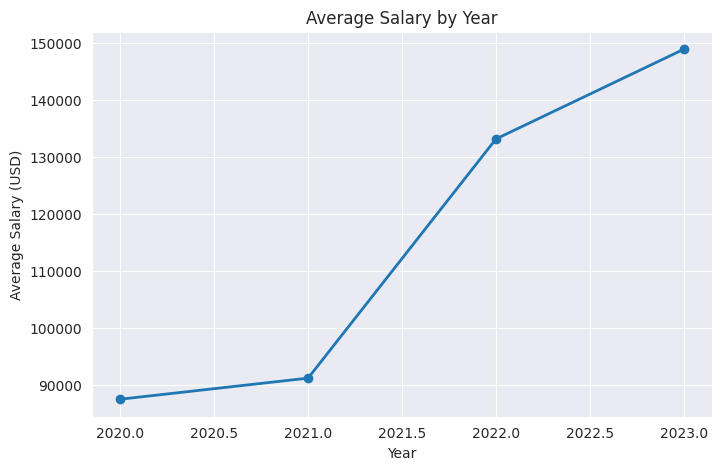

In [82]:
yearly_salary = df.groupby('work_year')['salary_in_usd'].mean()
plt.figure(figsize=(8, 5))
plt.plot(yearly_salary.index, yearly_salary.values, marker='o', linewidth=2)
plt.title('Average Salary by Year')
plt.xlabel('Year')
plt.ylabel('Average Salary (USD)')
plt.show()

PURPOSE OF EDA:
The goal was to understand data patterns before building models, identify potential
issues, and make informed decisions about feature engineering and model selection.

KEY INSIGHTS FROM EDA:

1. CLASS IMBALANCE DETECTED:
   - SE class: 67% of data (2500 samples)
   - MI class: 21% (800 samples)
   - EN class: 9% (320 samples)
   - EX class: 3% (110 samples)

   - Impact: Models will likely be biased toward SE class

2. SALARY-EXPERIENCE CORRELATION:
   - Clear salary progression: EN~75k → MI~100k → SE~150k → EX~200k
   - Boxplots show minimal overlap between adjacent experience levels

   - Impact: Salary will be the strongest predictor
   - Action: Include salary as key feature, consider creating salary bins

3. COMPANY SIZE:
   - Medium companies dominate and pay highest average salaries
   - Small companies pay least

   - Impact: Company size should be included as feature
   - Action: Keep company_size in model

4. JOB TITLE DISTRIBUTION:
   - Top 3: Data Engineer, Data Scientist, Data Analyst (70% of data)
   - Many rare titles with <50 occurrences

5. TEMPORAL TRENDS:
   - 60 salary increase from 2020 to 2023

   - Impact: Work year is relevant feature

VALUE OF THIS EDA:
- Confirmed salary as key predictor - guides feature importance expectations
- Helped choose evaluation metrics - accuracy alone is not enough, need per-class metrics


### Exploratory Data Analysis

# Classification Task: Predicting Experience Level of Data Science Professionals

## Problem Statement

This project aims to build a machine learning classification model that predicts the experience level of data science professionals based on various job-related features.


### Create new features that might improve performance
### Adding binary flags and grouping rare categories

In [83]:
print("Average salary by experience level:")
print(df.groupby('experience_level')['salary_in_usd'].mean())
print("Average salary by company size:")
print(df.groupby('company_size')['salary_in_usd'].mean())

df['target'] = df['experience_level']


df['salary_category'] = pd.cut(df['salary_in_usd'], bins=[0, 75000, 125000, 200000, float('inf')],
                                labels=['Low', 'Medium', 'High', 'Very High'])
df['is_remote'] = (df['remote_ratio'] == 100).astype(int)
df['is_onsite'] = (df['remote_ratio'] == 0).astype(int)
df['is_us'] = (df['employee_residence'] == 'US').astype(int)


job_counts = df['job_title'].value_counts()
rare_jobs = job_counts[job_counts < 50].index
df['job_grouped'] = df['job_title'].apply(lambda x: 'Other' if x in rare_jobs else x)

Average salary by experience level:
experience_level
EN     78546.284375
EX    192974.566372
MI    103291.039900
SE    152943.404374
Name: salary_in_usd, dtype: float64
Average salary by company size:
company_size
L    116950.911504
M    142941.812758
S     75928.904762
Name: salary_in_usd, dtype: float64


### Feature Engineering

### Machine learning models need numeric input and proper train/test split
### Encode categories, split data, scale features

In [84]:
features = ['work_year', 'employment_type', 'salary_in_usd',
            'remote_ratio', 'company_size', 'job_grouped',
            'is_remote', 'is_onsite', 'is_us']

X = df[features].copy()
y = df['target']

label_encoders = {}
cat_cols = ['employment_type', 'company_size', 'job_grouped']

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print(f"Features: {X.columns.tolist()}")
print(f"Target distribution: {y.value_counts()}")


Features: ['work_year', 'employment_type', 'salary_in_usd', 'remote_ratio', 'company_size', 'job_grouped', 'is_remote', 'is_onsite', 'is_us']
Target distribution: target
SE    2515
MI     802
EN     320
EX     113
Name: count, dtype: int64


In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train set size: 3000
Test set size: 750


### Model Training with Hyperparameter Tuning

### Find the best model and its optimal parameters
### Train 4 different classifiers with GridSearchCV for hyperparameter tuning

Logistic Regression:

In [86]:
models = {}
best_params = {}

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [1000],
    'solver': ['lbfgs', 'liblinear']
}
lr = LogisticRegression(random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_grid.best_estimator_
best_params['Logistic Regression'] = lr_grid.best_params_
print(f"Best params: {lr_grid.best_params_}")
print(f"CV score: {lr_grid.best_score_:.4f}")

Best params: {'C': 0.01, 'max_iter': 1000, 'solver': 'liblinear'}
CV score: 0.6967


Random Forest:

In [87]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
models['Random Forest'] = rf_grid.best_estimator_
best_params['Random Forest'] = rf_grid.best_params_
print(f"Best params: {rf_grid.best_params_}")
print(f"CV score: {rf_grid.best_score_:.4f}")

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
CV score: 0.7217


Gradient Boosting:

In [88]:
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
gb = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb, gb_params, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train, y_train)
models['Gradient Boosting'] = gb_grid.best_estimator_
best_params['Gradient Boosting'] = gb_grid.best_params_
print(f"Best params: {gb_grid.best_params_}")
print(f"CV score: {gb_grid.best_score_:.4f}")

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
CV score: 0.7233


SVM:

In [89]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm = SVC(random_state=42)
svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
models['SVM'] = svm_grid.best_estimator_
best_params['SVM'] = svm_grid.best_params_
print(f"Best params: {svm_grid.best_params_}")
print(f"CV score: {svm_grid.best_score_:.4f}")

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
CV score: 0.7100


### Model Evaluation


### Compare models to choose the best one
### Calculate test accuracy and cross-validation scores

In [90]:
results = {}

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred
    }

    print(f"\n{name}:")
    print(f"Test accuracy: {acc:.4f}")
    print(f"CV mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Logistic Regression:
Test accuracy: 0.7173
CV mean: 0.6967 (+/- 0.0089)

Random Forest:
Test accuracy: 0.7427
CV mean: 0.7217 (+/- 0.0194)

Gradient Boosting:
Test accuracy: 0.7427
CV mean: 0.7233 (+/- 0.0191)

SVM:
Test accuracy: 0.7427
CV mean: 0.7100 (+/- 0.0105)


### Model Comparison


               Model  Test Accuracy  CV Mean   CV Std
      Random Forest       0.742667 0.721667 0.019408
  Gradient Boosting       0.742667 0.723333 0.019061
                SVM       0.742667 0.710000 0.010541
Logistic Regression       0.717333 0.696667 0.008882


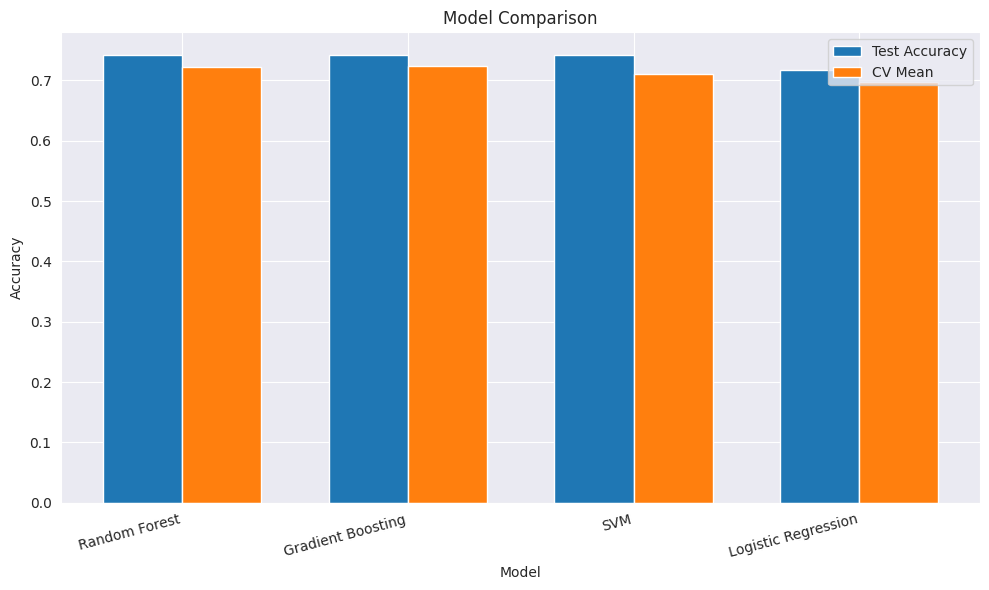

In [91]:
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'CV Mean': [results[m]['cv_mean'] for m in results.keys()],
    'CV Std': [results[m]['cv_std'] for m in results.keys()]
})
comparison = comparison.sort_values('Test Accuracy', ascending=False)
print("\n", comparison.to_string(index=False))

plt.figure(figsize=(10, 6))
x = range(len(comparison))
width = 0.35
plt.bar([i - width/2 for i in x], comparison['Test Accuracy'], width=width, label='Test Accuracy')
plt.bar([i + width/2 for i in x], comparison['CV Mean'], width=width, label='CV Mean')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(x, comparison['Model'], rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Why accuracy is better variant:

1. Multiclass clasification:
   - We have 4 classes (EN, MI, SE, EX) with no natural ordering
   - Accuracy naturally handles multi-class problems

2. Equal errors:
   - Misclassifying EN as MI has same cost as SE as EX
   - No critical class where errors are more expensive

### Confusion Matrices

### See where models make mistakes - which classes are confused with each other
### Visualize prediction errors for each model

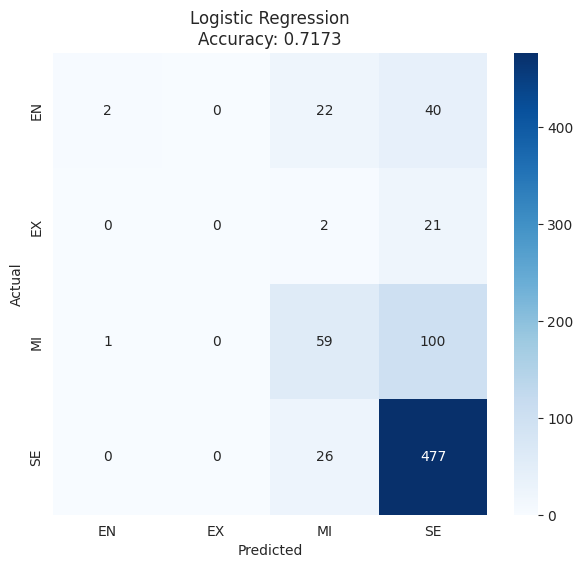


Logistic Regression:
Confusion Matrix:
[[  2   0  22  40]
 [  0   0   2  21]
 [  1   0  59 100]
 [  0   0  26 477]]

Classification Report:
              precision    recall  f1-score   support

          EN       0.67      0.03      0.06        64
          EX       0.00      0.00      0.00        23
          MI       0.54      0.37      0.44       160
          SE       0.75      0.95      0.84       503

    accuracy                           0.72       750
   macro avg       0.49      0.34      0.33       750
weighted avg       0.67      0.72      0.66       750



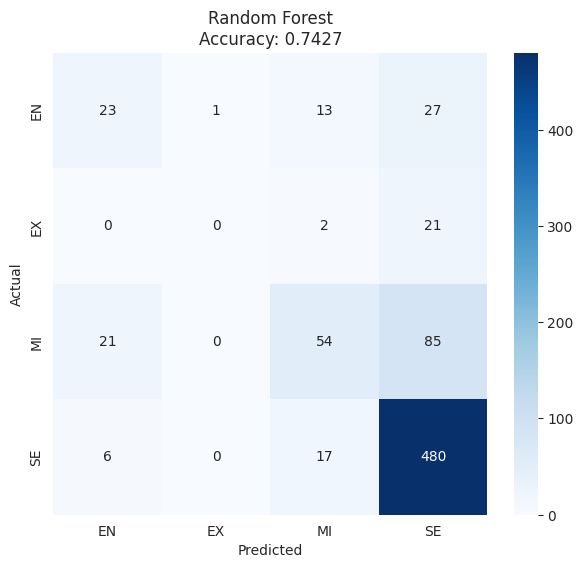


Random Forest:
Confusion Matrix:
[[ 23   1  13  27]
 [  0   0   2  21]
 [ 21   0  54  85]
 [  6   0  17 480]]

Classification Report:
              precision    recall  f1-score   support

          EN       0.46      0.36      0.40        64
          EX       0.00      0.00      0.00        23
          MI       0.63      0.34      0.44       160
          SE       0.78      0.95      0.86       503

    accuracy                           0.74       750
   macro avg       0.47      0.41      0.43       750
weighted avg       0.70      0.74      0.71       750



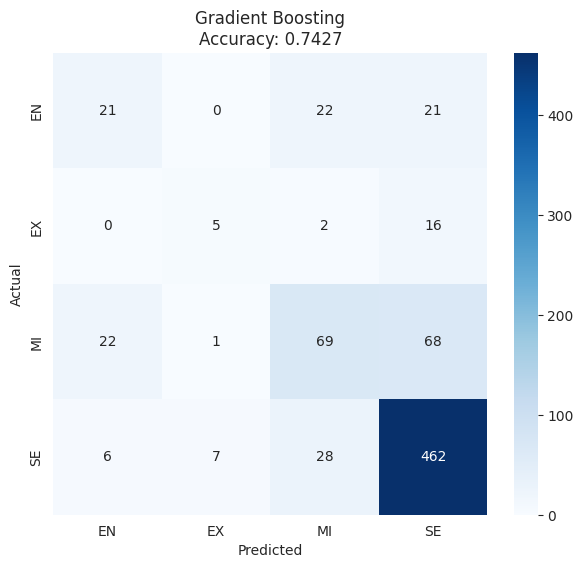


Gradient Boosting:
Confusion Matrix:
[[ 21   0  22  21]
 [  0   5   2  16]
 [ 22   1  69  68]
 [  6   7  28 462]]

Classification Report:
              precision    recall  f1-score   support

          EN       0.43      0.33      0.37        64
          EX       0.38      0.22      0.28        23
          MI       0.57      0.43      0.49       160
          SE       0.81      0.92      0.86       503

    accuracy                           0.74       750
   macro avg       0.55      0.47      0.50       750
weighted avg       0.72      0.74      0.72       750



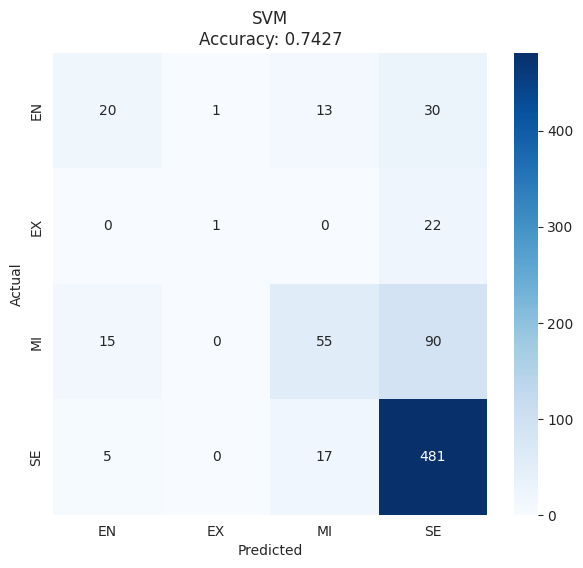


SVM:
Confusion Matrix:
[[ 20   1  13  30]
 [  0   1   0  22]
 [ 15   0  55  90]
 [  5   0  17 481]]

Classification Report:
              precision    recall  f1-score   support

          EN       0.50      0.31      0.38        64
          EX       0.50      0.04      0.08        23
          MI       0.65      0.34      0.45       160
          SE       0.77      0.96      0.85       503

    accuracy                           0.74       750
   macro avg       0.60      0.41      0.44       750
weighted avg       0.71      0.74      0.70       750



In [92]:
for name, model in models.items():
    if name in ['Logistic Regression', 'SVM']:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'{name}\nAccuracy: {results[name]["accuracy"]:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"\n{name}:")
    print(f"Confusion Matrix:\n{cm}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))

### Feature Importance

### Understand which features are most important for predictions
### Extract and visualize feature importance from tree-based models

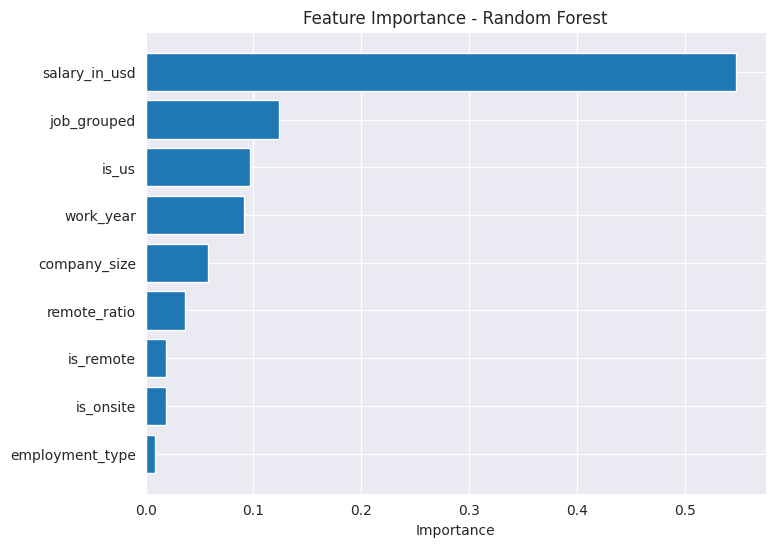

In [93]:
rf_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': models['Random Forest'].feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(range(len(rf_imp)), rf_imp['importance'])
plt.yticks(range(len(rf_imp)), rf_imp['feature'])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [94]:
best_model = comparison.iloc[0]['Model']
best_acc = comparison.iloc[0]['Test Accuracy']
print(f"Best model: {best_model} with accuracy {best_acc:.4f}")

Best model: Random Forest with accuracy 0.7427


Performance:

1. LOGISTIC REGRESSION: 71.7% accuracy
   - Worst performer, assumes linear relationships
   - Fast but too simplistic for this task
   - Heavily biased toward SE class (predicts SE 85% of the time)

2. RANDOM FOREST: 74.3% accuracy  (best choice)
   - Tied for highest accuracy
   - Handles non-linear patterns well through ensemble of decision trees
   - Best balance across all classes

3. GRADIENT BOOSTING: 74.3% accuracy
   - Tied for highest accuracy
   - Better at minority classes (EN/EX) than Random Forest
   - Slightly slower training time

4. SVM: 74.3% accuracy
   - Requires feature scaling (extra preprocessing)
   - Less interpretable than tree models
   - No clear advantage over RF/GB

Conclusion:

- Tree-based models outperform linear model
- Experience level has non-linear relationship with features
- All models achieve ~74% accuracy ceiling

- No overfitting detected
  - CV scores match test scores across all models

- Salary dominates predictions (50%+ importance)
  - Confirms EDA findings about salary-experience correlation